Epoch 01 | Train Acc: 37.25% | Val Acc: 44.93% | Loss: 1.7420
Epoch 02 | Train Acc: 46.13% | Val Acc: 48.67% | Loss: 1.5077
Epoch 03 | Train Acc: 49.29% | Val Acc: 50.23% | Loss: 1.4159
Epoch 04 | Train Acc: 51.59% | Val Acc: 53.04% | Loss: 1.3537
Epoch 05 | Train Acc: 53.45% | Val Acc: 53.09% | Loss: 1.3017
Epoch 06 | Train Acc: 55.37% | Val Acc: 54.68% | Loss: 1.2498
Epoch 07 | Train Acc: 56.70% | Val Acc: 54.94% | Loss: 1.2109
Epoch 08 | Train Acc: 58.04% | Val Acc: 55.45% | Loss: 1.1716
Epoch 09 | Train Acc: 59.45% | Val Acc: 55.61% | Loss: 1.1372
Epoch 10 | Train Acc: 60.50% | Val Acc: 56.45% | Loss: 1.1022
Epoch 11 | Train Acc: 61.73% | Val Acc: 56.41% | Loss: 1.0715
Epoch 12 | Train Acc: 63.04% | Val Acc: 56.20% | Loss: 1.0325
Epoch 13 | Train Acc: 64.07% | Val Acc: 56.57% | Loss: 1.0027
Epoch 14 | Train Acc: 65.19% | Val Acc: 56.83% | Loss: 0.9733
Epoch 15 | Train Acc: 66.15% | Val Acc: 57.21% | Loss: 0.9428
Epoch 16 | Train Acc: 67.34% | Val Acc: 58.07% | Loss: 0.9086
Epoch 17

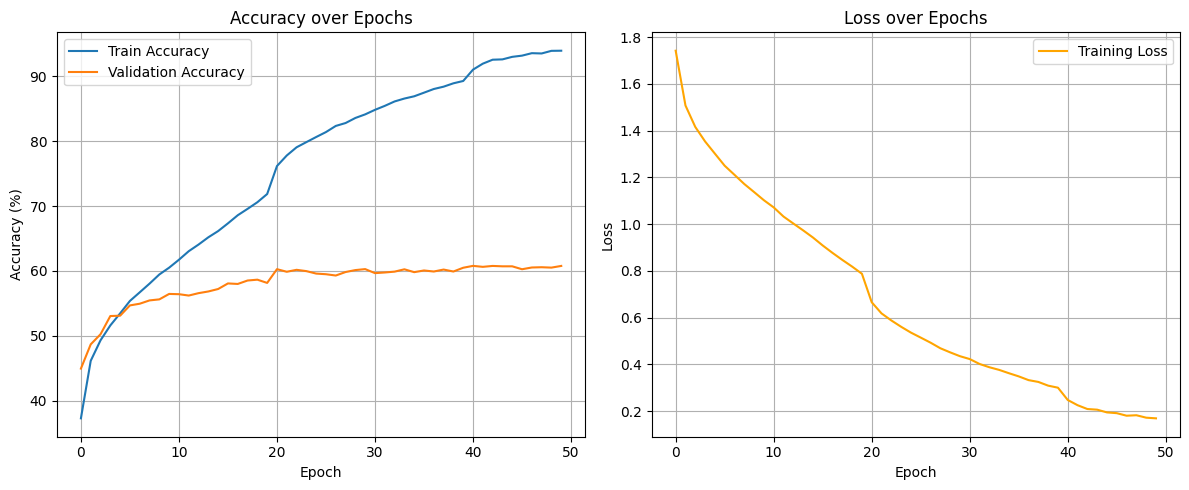

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Better CIFAR-10 normalization values (mean/std per channel)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

# Improved FCNN model
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(4096, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
model = FCNN().to(device)

# Xavier Initialization for better convergence
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Trackers
train_acc_list, val_acc_list, loss_list = [], [], []

# Evaluation function
def evaluate_model():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# Training loop
def train_model(epochs=50):
    for epoch in range(epochs):
        model.train()
        correct, total, total_loss = 0, 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            total_loss += loss.item()

        scheduler.step()

        train_acc = 100. * correct / total
        val_acc = evaluate_model()
        avg_loss = total_loss / len(trainloader)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        loss_list.append(avg_loss)

        print(f"Epoch {epoch+1:02} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Loss: {avg_loss:.4f}")

# Start training
start = time.time()
train_model(epochs=50)
print(f"Training Time: {(time.time() - start):.2f} seconds")

# Final accuracy
print("Final Test Accuracy:", evaluate_model())

# Plot metrics
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(val_acc_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss_list, label='Training Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
